# Emily Chin

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load in data (USDA + Climate Trace Data)

In [31]:
df = pd.read_csv("/Users/emilychin/Desktop/ds207/crop-yield/data/clean_data.csv")
df

,Year,State,County,Crop Fire Emissions,Crop Residue Emissions,Manure Fertilizer Emissions,Soil Emissions,Synthetic Fertilizer Emissions,Corn Yield
0,2021,ALABAMA,BALDWIN,8564.807217,4668.08706,10456.16208,59019.547184,45922.77690,151.282051
1,2021,ALABAMA,BARBOUR,589.283512,1090.00710,4432.23144,33297.901576,28706.69802,183.478261
2,2021,ALABAMA,BLOUNT,296.569885,4114.03356,5180.99400,24484.589499,29192.38686,147.142857
3,2021,ALABAMA,CALHOUN,0.022775,698.57970,1804.48632,21651.332000,11389.65828,157.000000
4,2021,ALABAMA,CHEROKEE,0.000035,1162.95270,2349.95124,22010.477311,16576.77840,168.250000
...,...,...,...,...,...,...,...,...,...
4306,2023,WISCONSIN,WAUKESHA,62.165743,9727.07736,4087.13760,15827.318007,30285.05298,168.456853
4307,2023,WISCONSIN,WAUPACA,63.359779,17013.13614,8555.46510,28315.972099,63707.73318,118.760611
4308,2023,WISCONSIN,WAUSHARA,109.859461,40973.95302,14668.01154,23911.898372,66009.59274,159.257143
4309,2023,WISCONSIN,WINNEBAGO,226.032869,13670.53506,5632.42134,15798.831113,37229.02092,131.563126


## EDA

In [32]:
list(df)

['Year',
 'State',
 'County',
 'Crop Fire Emissions',
 'Crop Residue Emissions',
 'Manure Fertilizer Emissions',
 'Soil Emissions',
 'Synthetic Fertilizer Emissions',
 'Corn Yield']

## Fertilizer Emissions vs. Corn Yield

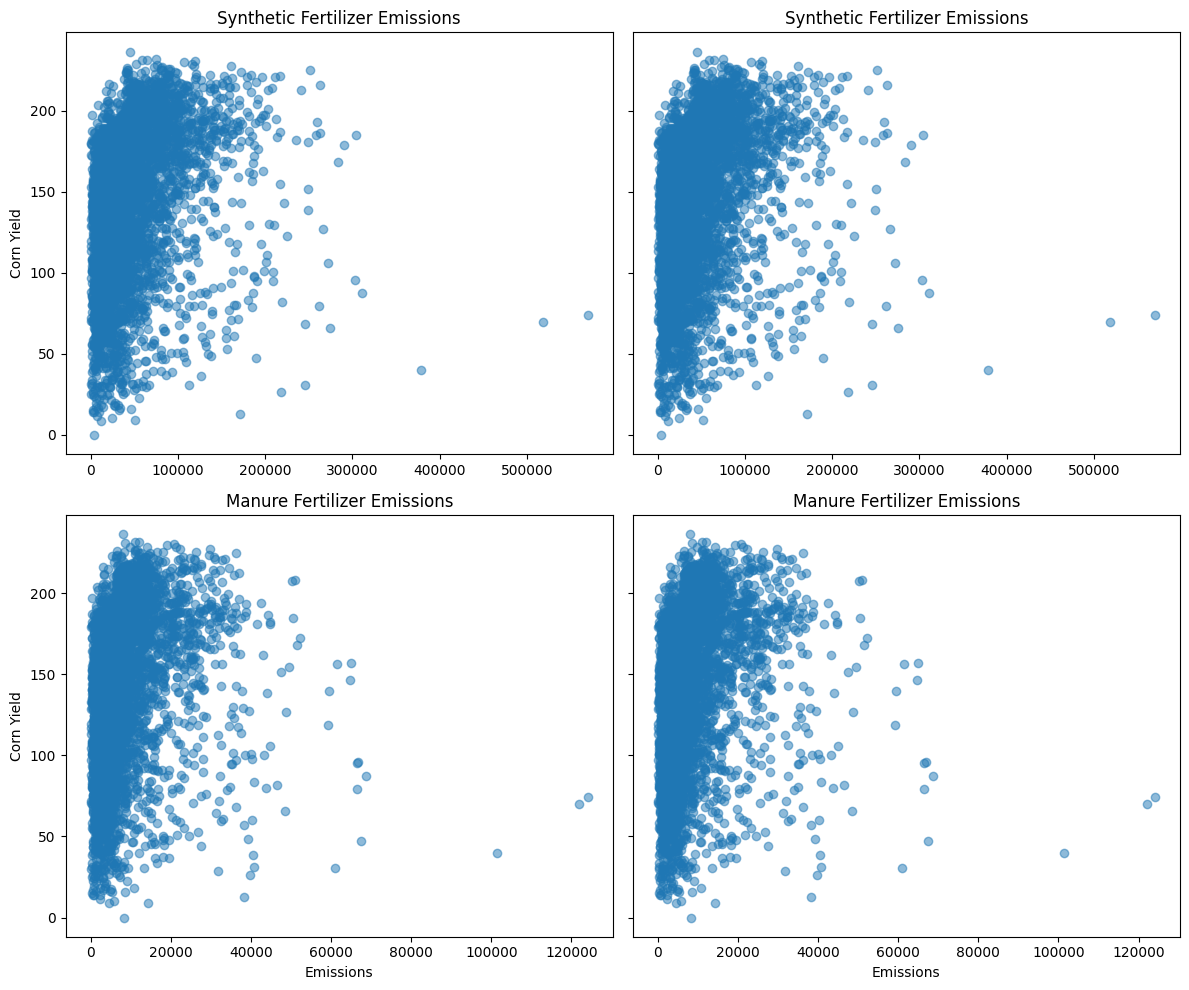

In [34]:
fig, ax = plt.subplots(2, 2, figsize=(12,10), sharey=True)

# Synthetic CO2
ax[0,0].scatter(df['Synthetic Fertilizer Emissions'], df['Corn Yield'], alpha=0.5)
ax[0,0].set_title('Synthetic Fertilizer Emissions')
ax[0,0].set_ylabel('Corn Yield')

# Synthetic N2O
ax[0,1].scatter(df['Synthetic Fertilizer Emissions'], df['Corn Yield'], alpha=0.5)
ax[0,1].set_title('Synthetic Fertilizer Emissions')

# Manure CO2
ax[1,0].scatter(df['Manure Fertilizer Emissions'], df['Corn Yield'], alpha=0.5)
ax[1,0].set_title('Manure Fertilizer Emissions')
ax[1,0].set_xlabel('Emissions')
ax[1,0].set_ylabel('Corn Yield')

# Manure N2O
ax[1,1].scatter(df['Manure Fertilizer Emissions'], df['Corn Yield'], alpha=0.5)
ax[1,1].set_title('Manure Fertilizer Emissions')
ax[1,1].set_xlabel('Emissions')

plt.tight_layout()
plt.show();

## Distribution of Features

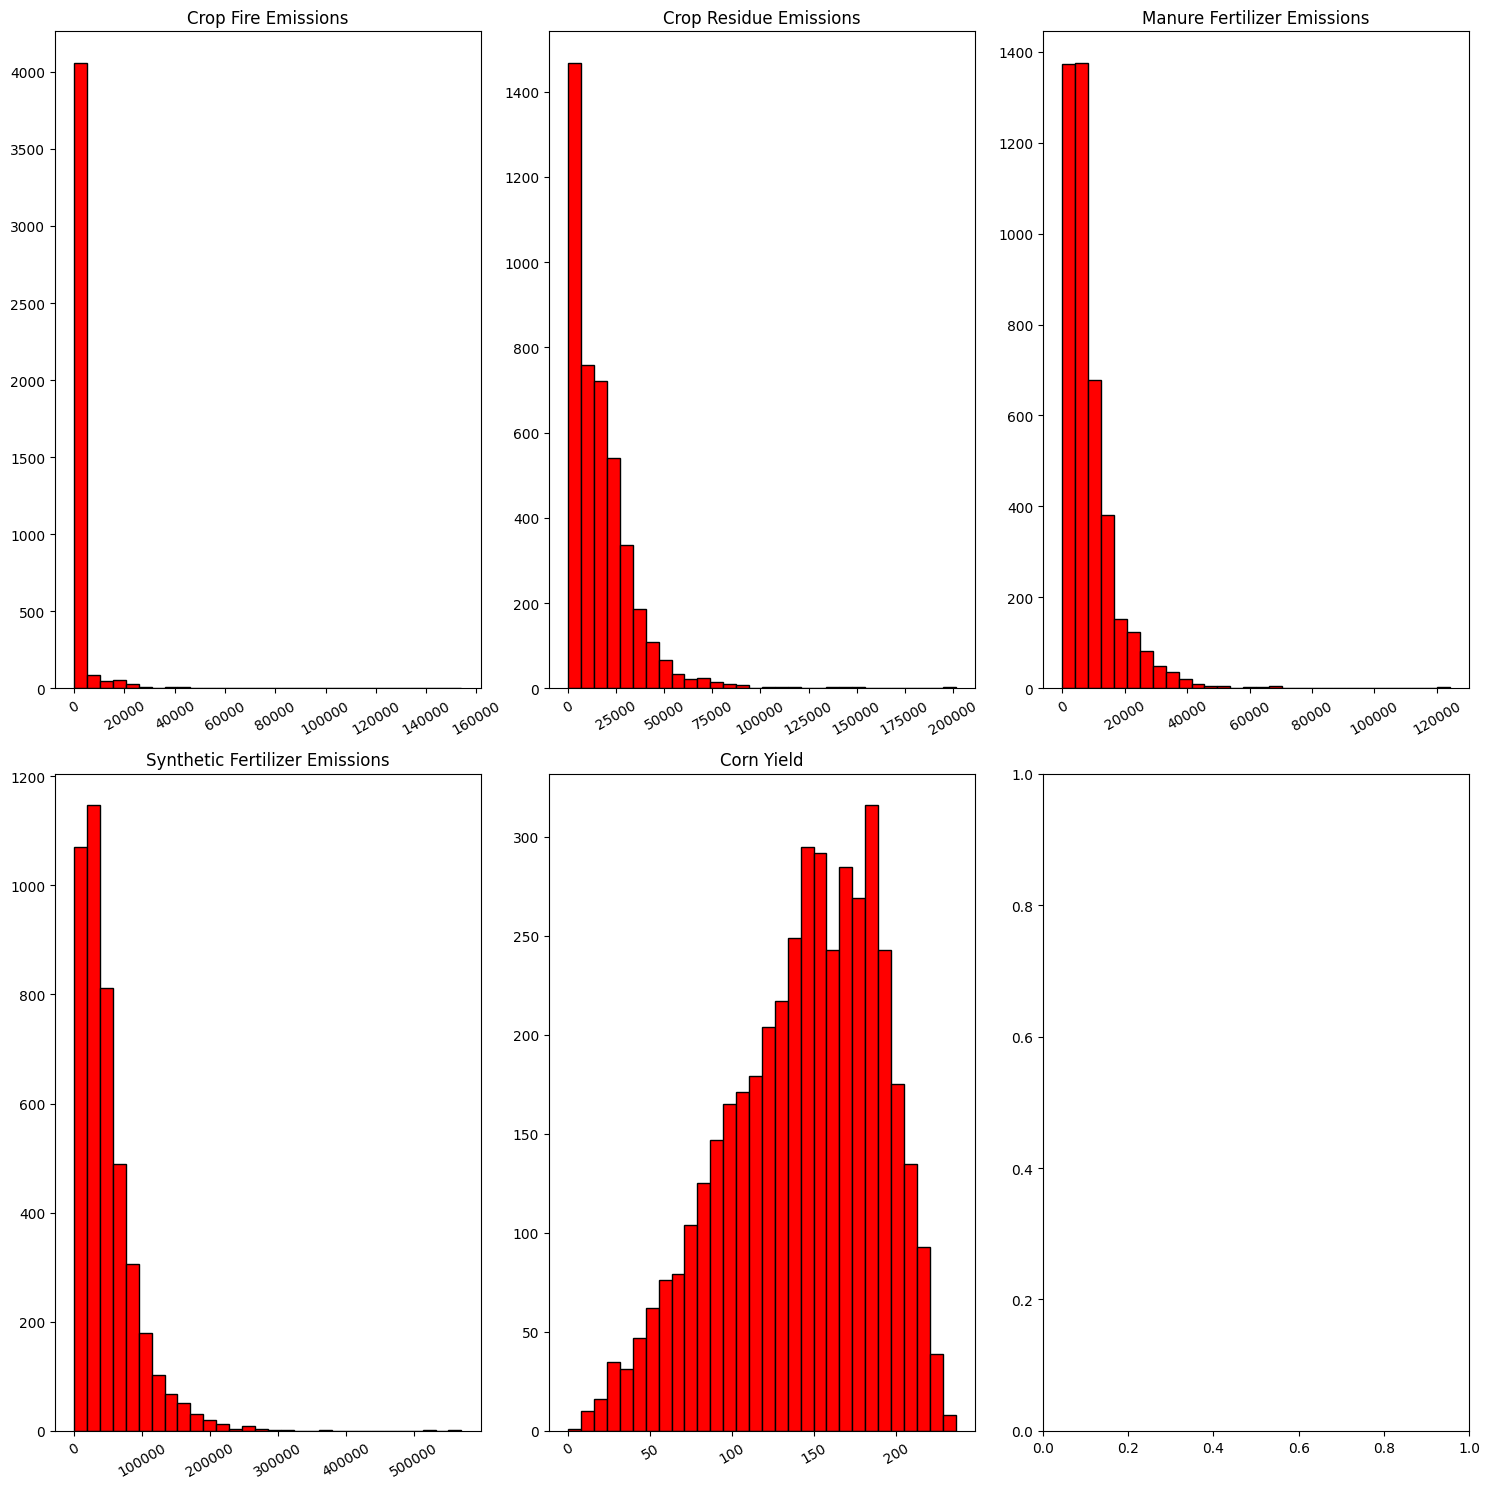

In [41]:
emission_cols = ['Crop Fire Emissions', 
                 'Crop Residue Emissions',
                 'Manure Fertilizer Emissions',
                 'Synthetic Fertilizer Emissions']

yield_cols = ['Corn Yield']

fig, axes = plt.subplots(2, 3, figsize=(15,15))
axes = axes.flatten()

for i, col in enumerate(emission_cols + yield_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='red', edgecolor='k')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show();

## Correlation of Features

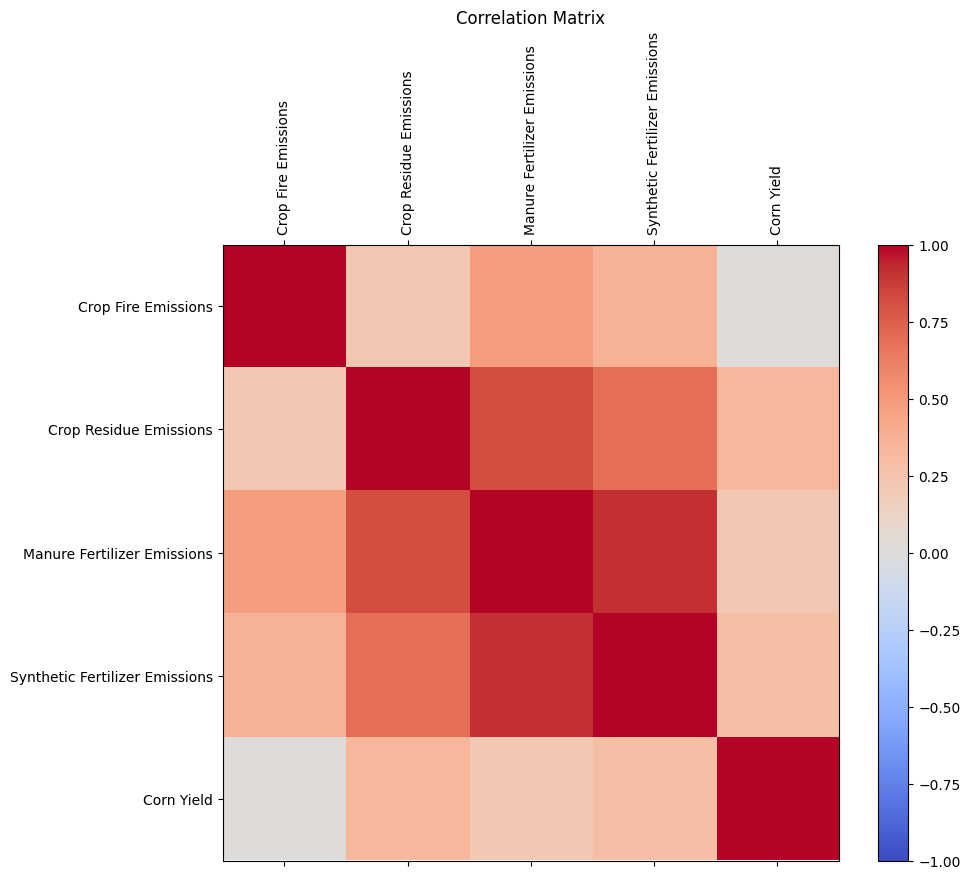

In [42]:
numeric_cols = emission_cols + yield_cols 
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10,8))
cax = ax.matshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=90)
ax.set_yticklabels(numeric_cols)
plt.title("Correlation Matrix")
plt.show();

## Time Series Corn Yield

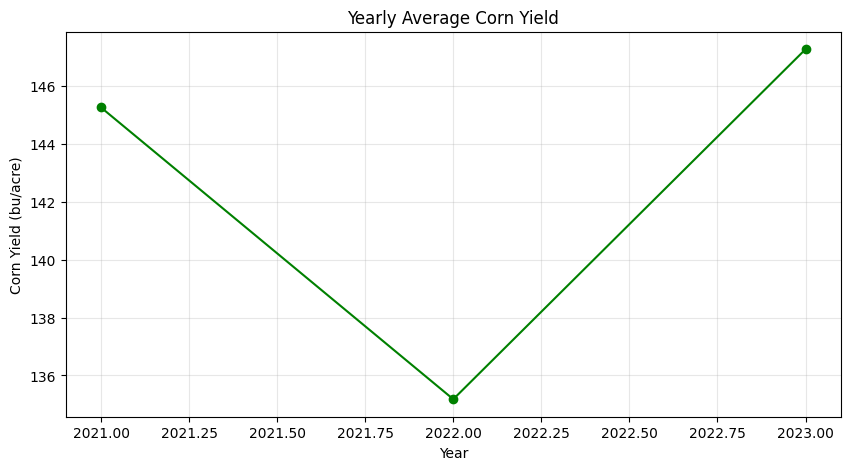

In [47]:
yearly = df.groupby('Year')[['Corn Yield', 
                             'Synthetic Fertilizer Emissions', 
                             'Manure Fertilizer Emissions']].mean()

plt.figure(figsize=(10,5))
plt.plot(yearly.index, yearly['Corn Yield'], marker='o', color='green')
plt.title('Yearly Average Corn Yield')
plt.xlabel('Year')
plt.ylabel('Corn Yield (bu/acre)')
plt.grid(alpha=0.3)
plt.show();

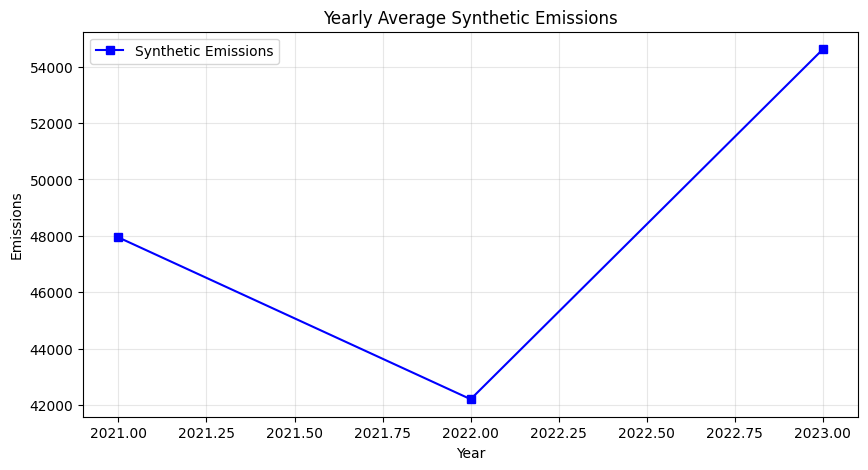

In [50]:
plt.figure(figsize=(10,5))
plt.plot(yearly.index, yearly['Synthetic Fertilizer Emissions'], marker='s', color='blue', label='Synthetic Emissions')
plt.title('Yearly Average Synthetic Emissions')
plt.xlabel('Year')
plt.ylabel('Emissions')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

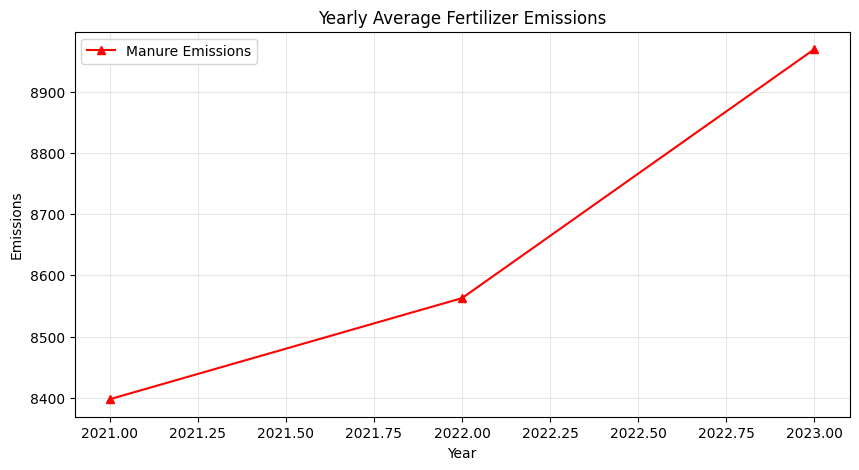

In [49]:
plt.figure(figsize=(10,5))
plt.plot(yearly.index, yearly['Manure Fertilizer Emissions'], marker='^', color='red', label='Manure Emissions')
plt.title('Yearly Average Manure Emissions')
plt.xlabel('Year')
plt.ylabel('Emissions')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
